# Step 5: Data Visualization & Executive Reporting Dashboards

**Objective:** Transform our SQL views and statistical outputs into clean, publication-ready visuals for stakeholders.

**Visual Toolkit:**
1. **Funnel Drop-off Diagram:** Stage-by-stage progression.
2. **Channel Efficiency Comparison:** Identifying high-performing acquisition paths.
3. **Monthly Cohort Heatmap:** Cohort retention matrix over time.
4. **A/B Test Confidence Interval Plot:** Visualizing conversion lift and margin of error.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
from urllib.parse import quote_plus

# Database Connection
load_dotenv(override=True)

DB_USER = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_HOST = os.getenv('DB_HOST', '127.0.0.1').strip()
DB_PORT = os.getenv('DB_PORT', '3306').strip()
DB_NAME = os.getenv('DB_NAME')

encoded_password = quote_plus(DB_PASSWORD)
connection_string = f"mysql+pymysql://{DB_USER}:{encoded_password}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(connection_string, pool_pre_ping=True)

# Global Chart Styling Settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

print("✅ Plotting engine configured and reconnected to MySQL!")

✅ Plotting engine configured and reconnected to MySQL!


In [3]:
from sqlalchemy import text

# Re-create the view directly via SQLAlchemy
create_funnel_view_sql = """
CREATE OR REPLACE VIEW v_funnel_conversion_rates AS
SELECT 
    COUNT(DISTINCT CASE WHEN event_type = 'signup' THEN user_id END) AS total_signups,
    COUNT(DISTINCT CASE WHEN event_type = 'activation' THEN user_id END) AS total_activations,
    COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_id END) AS total_purchases,
    ROUND(COUNT(DISTINCT CASE WHEN event_type = 'activation' THEN user_id END) * 100.0 / 
          NULLIF(COUNT(DISTINCT CASE WHEN event_type = 'signup' THEN user_id END), 0), 2) AS signup_to_activation_pct,
    ROUND(COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_id END) * 100.0 / 
          NULLIF(COUNT(DISTINCT CASE WHEN event_type = 'activation' THEN user_id END), 0), 2) AS activation_to_purchase_pct,
    ROUND(COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_id END) * 100.0 / 
          NULLIF(COUNT(DISTINCT CASE WHEN event_type = 'signup' THEN user_id END), 0), 2) AS overall_conversion_pct
FROM events;
"""

with engine.connect() as conn:
    conn.execute(text(create_funnel_view_sql))
    conn.commit()

print("✅ View 'v_funnel_conversion_rates' created successfully!")

✅ View 'v_funnel_conversion_rates' created successfully!


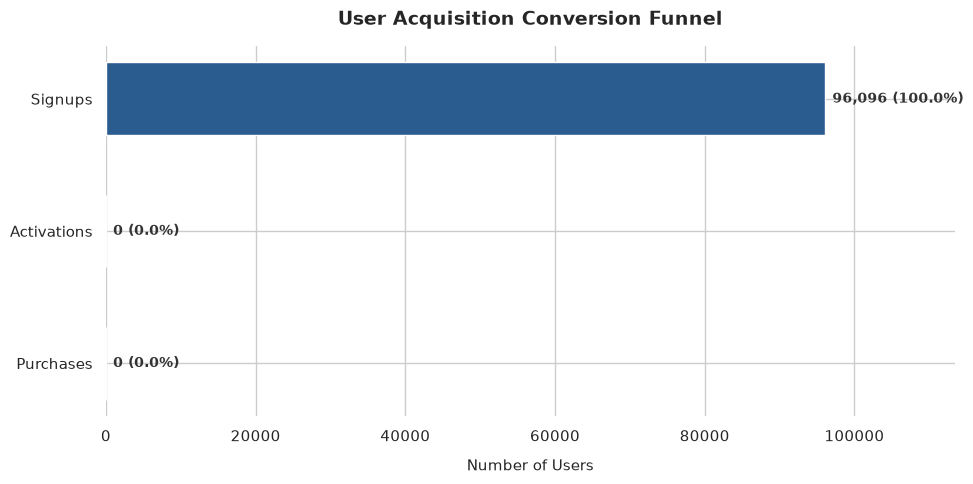

In [4]:
# Fetch overall funnel view from MySQL
funnel_data = pd.read_sql("SELECT * FROM v_funnel_conversion_rates;", con=engine)

stages = ['Signups', 'Activations', 'Purchases']
counts = [
    funnel_data['total_signups'].iloc[0],
    funnel_data['total_activations'].iloc[0],
    funnel_data['total_purchases'].iloc[0]
]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2b5c8f', '#4682b4', '#00a86b']

bars = ax.barh(stages[::-1], counts[::-1], color=colors[::-1], height=0.55)

# Add value & percentage labels to bars
total_signups = counts[0]
for bar in bars:
    width = bar.get_width()
    pct = (width / total_signups) * 100
    ax.text(width + (total_signups * 0.01), bar.get_y() + bar.get_height()/2,
            f"{width:,.0f} ({pct:.1f}%)",
            va='center', ha='left', fontsize=10, fontweight='bold', color='#333333')

ax.set_title("User Acquisition Conversion Funnel", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Number of Users", fontsize=11, labelpad=10)
ax.set_xlim(0, total_signups * 1.18)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_656\3208117887.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


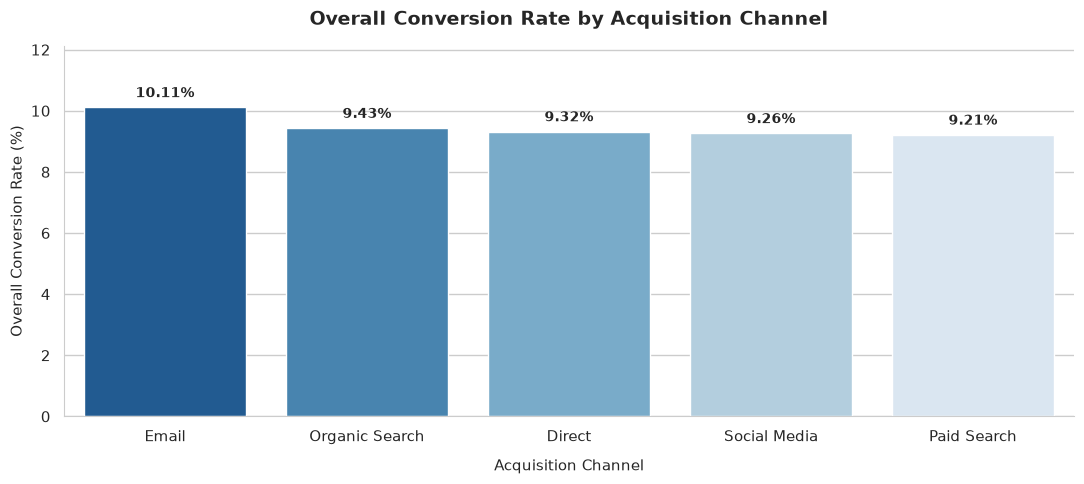

In [5]:
# Fetch channel breakdown from MySQL
channel_df = pd.read_sql("SELECT * FROM v_channel_performance;", con=engine)

fig, ax = plt.subplots(figsize=(11, 5))
palette = sns.color_palette("Blues_r", len(channel_df))

bars = sns.barplot(
    data=channel_df, 
    x='acquisition_channel', 
    y='overall_conversion_pct', 
    palette=palette, 
    ax=ax
)

for p in bars.patches:
    height = p.get_height()
    ax.annotate(f"{height:.2f}%",
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points',
                fontsize=10, fontweight='bold')

ax.set_title("Overall Conversion Rate by Acquisition Channel", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Acquisition Channel", fontsize=11, labelpad=10)
ax.set_ylabel("Overall Conversion Rate (%)", fontsize=11)
ax.set_ylim(0, channel_df['overall_conversion_pct'].max() * 1.2)
sns.despine()
plt.tight_layout()
plt.show()

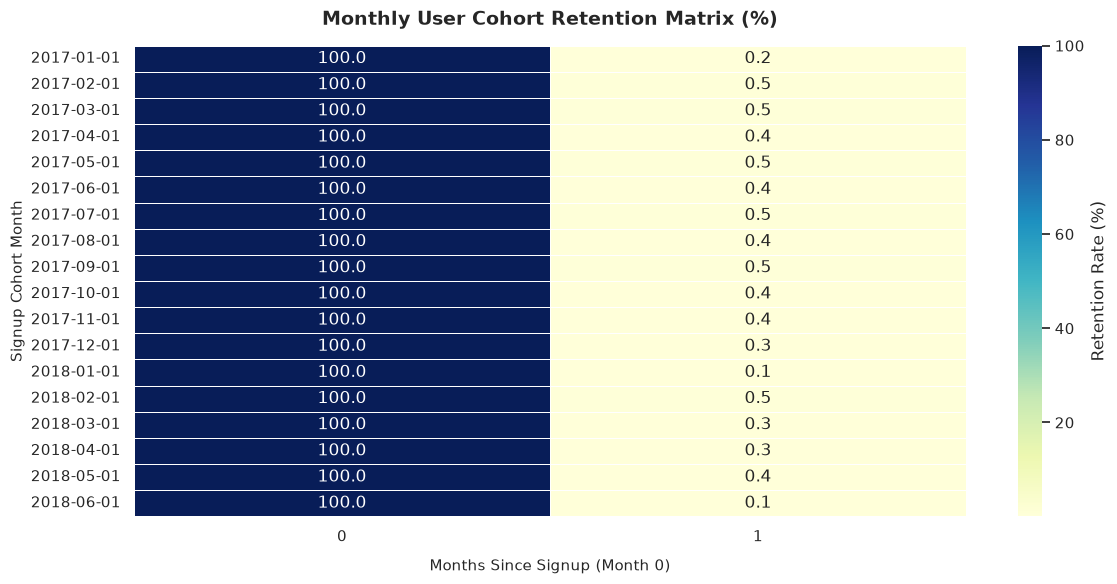

In [7]:
# Fetch cohort view from MySQL
cohort_df = pd.read_sql("SELECT * FROM v_monthly_cohort_retention;", con=engine)

# Pivot into matrix format
cohort_pivot = cohort_df.pivot(index='cohort_month', columns='month_number', values='active_users')

# Calculate retention percentages relative to Month 0
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100

plt.figure(figsize=(12, 6))
sns.heatmap(
    retention_matrix, 
    annot=True, 
    fmt=".1f", 
    cmap="YlGnBu", 
    cbar_kws={'label': 'Retention Rate (%)'},
    linewidths=0.5
)

plt.title("Monthly User Cohort Retention Matrix (%)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Months Since Signup (Month 0)", fontsize=11, labelpad=10)
plt.ylabel("Signup Cohort Month", fontsize=11)
plt.tight_layout()
plt.show()

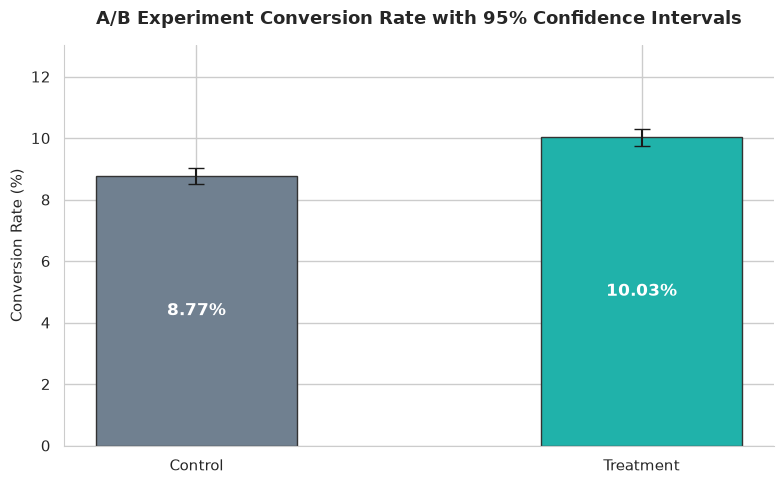

In [8]:
# Fetch raw A/B assignment data for calculating error bounds
ab_raw = pd.read_sql("SELECT group_assignment, converted FROM ab_test_assignment;", con=engine)

ab_stats = ab_raw.groupby('group_assignment')['converted'].agg(['mean', 'count', 'std']).reset_index()
ab_stats['se'] = ab_stats['std'] / np.sqrt(ab_stats['count'])
ab_stats['ci95'] = ab_stats['se'] * 1.96
ab_stats['conversion_pct'] = ab_stats['mean'] * 100
ab_stats['ci95_pct'] = ab_stats['ci95'] * 100

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#708090', '#20b2aa']

bars = ax.bar(
    ab_stats['group_assignment'].str.capitalize(), 
    ab_stats['conversion_pct'], 
    yerr=ab_stats['ci95_pct'], 
    capsize=6, 
    color=colors, 
    width=0.45,
    edgecolor='#333333'
)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval / 2, f"{yval:.2f}%", ha='center', va='center', color='white', fontweight='bold', fontsize=12)

ax.set_title("A/B Experiment Conversion Rate with 95% Confidence Intervals", fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel("Conversion Rate (%)", fontsize=11)
ax.set_ylim(0, ab_stats['conversion_pct'].max() * 1.3)
sns.despine()
plt.tight_layout()
plt.show()